# Load necessary files

In [1225]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [1341]:
tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, len(tokens))
        #self.fc2 = nn.Linear(len(tokens), len(tokens))
        
    def forward(self, x, h0=None, return_state_only = False):
        if h0 == None:
            out, h0 = self.rnn(x)
        else:   
            out, h0 = self.rnn(x, h0)
        #out = torch.nn.functional.relu(self.fc1(out[0]))
        # print(out.shape)

        if return_state_only:
            return out, h0
            
        out = self.fc1(out[:,-1,:])
        # out = torch.nn.functional.softmax(out, dim=2)
        return out, h0

In [1227]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [1228]:
class Dataset_converter_compressed(Dataset):
    def __init__(self, data, compression=2, working_memory=1, short_term_memory=8):
        # data_ = ''

        # print(data[:100])
        # for ii, ch in enumerate(data):
        #     if ii%compression==0:
        #         data_ += ch
        # print(data_[:100])       
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=int)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    if kk%compression==0:
                        self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                        one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [253]:
def _get_member(community, n_members, clockwise=True):
    seq = chr(community*n_members + ord('A'))
    
    if clockwise:
        next_token = chr(community*n_members + ord('A') + 1)
    else:
        next_token = chr(community*n_members + ord('A') + n_members-1)

    for _ in range(n_members-1):
        seq += next_token

        if clockwise:
            next_token = chr(ord(next_token) + 1)
        else:
            next_token = chr(ord(next_token) - 1)

    seq += seq[0]
    return seq 

def get_sequence(n_samples, n_community, n_members, random_state=0):
    
    """
    Generate data sequence divided into communities.

    Parameters
    ----------
    n_samples : int
        Total number of tokens to sample.
    n_community : int
        Total number of community.
    n_members : int
        Total number of members in each community.
    random_state : int, RandomState instance, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.

    Returns
    -------
    out : array of shape [n_samples]
        The generated sequence of tokens.
    """

    if random_state != None:
        np.random.seed(random_state)

    visits = []
    direction = []
    total_community_visit = int(np.ceil(n_samples/n_members))
    
    for ii in range(total_community_visit):
        visits.append(
            np.random.choice(n_community)
        )

        if ii == 0 or ii == 1:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] == visits[-1]:
            direction.append(False)
        elif visits[-2] != visits[-1] and visits[-3] == visits[-1]:
            direction.append(True)
        elif visits[-2] == visits[-1] and visits[-3] != visits[-1]:
            direction.append(True)
        else:
            direction.append(False)

    out = ''
    for ii, community in enumerate(visits):
        out += _get_member(community, n_members, clockwise=direction[ii]) + chr(ord('A')+n_community*n_members)

    return out[:n_samples]
        

# Load dataset and perform the experiment

In [1083]:
### initial training ###
total_samples = 250000
initial_training_sample = 2000
sleeping_duration = 200000
working_memory = 1
short_term_memory = 1
working_memory_after_sleep = 4
hidden_size = 20
num_layers = 1
lr = 1e-3
lr_sleep = 5e-4
reps = 10
test_acc = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    
    
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for X, y in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')
    
    
    ## train sleep models ##
    sleep_models = []
    for compression in range(2,working_memory_after_sleep+1):
        print('Doing sleep model ',compression-1)
        
        data_set = Dataset_converter_compressed(data[initial_training_sample:initial_training_sample+sleeping_duration], compression, compression, 1)
        # print(len(data_set))
        sleep_models.append(
            RNN(len(tokens), hidden_size, num_layers)
        )
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(sleep_models[-1].parameters(), lr=lr_sleep, momentum=.95)
        criterion = torch.nn.CrossEntropyLoss()
    
        correct_ = np.zeros(1000,dtype=float)
        ii = 0
        for X, y in train_loader:
            optimizer.zero_grad()
    
            if ii == 0:
                predicted_y, hidden = sleep_models[-1](X)
            else:
                predicted_y, hidden = sleep_models[-1](X, mem)
                
            loss = criterion(predicted_y, y)
    
            # if ii<20000:
            loss.backward()
            optimizer.step()
    
            ii += 1
            with torch.no_grad():
                mem = hidden.clone()
    
                true_y = y.argmax(axis=1)
                estimated_y = predicted_y.argmax(axis=1)
    
                if true_y == estimated_y:
                    correct_[ii%1000] = 1
                else:
                    correct_[ii%1000] = 0
    
                if ii%10000 == 0:
                    print(f'Iter : {ii+1}, loss: {loss:.4f}, accuracy: {np.sum(correct_)/ii if ii<1000 else np.sum(correct_)/1000:.4f}')


    ###### after sleep ######
    data_set = Dataset_converter(data[initial_training_sample+sleeping_duration:initial_training_sample+sleeping_duration+10000], working_memory_after_sleep, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

    # correct = np.zeros(1000,dtype=float)
    ii = 0
    hidden_sleep = [hidden.clone()]*(working_memory_after_sleep-1)
    for X, y in test_loader:
    
        with torch.no_grad():
            if ii == 0:
                predicted_y, hidden = main_model(X[0,0,-len(tokens):].reshape(1,1,len(tokens)))
            else:
                predicted_y, hidden = main_model(X[0,0,-len(tokens):].reshape(1,1,len(tokens)), hidden)
    
            for jj, model in enumerate(sleep_models):
                if ii == 0:
                    predicted_y_, hidden_ = model(X[0,0,-(jj+2)*len(tokens):-(jj+1)*len(tokens)].reshape(1,1,len(tokens)))
                else:
                    predicted_y_, hidden_ = model(X[0,0,-(jj+2)*len(tokens):-(jj+1)*len(tokens)].reshape(1,1,len(tokens)), hidden_sleep[jj])
    
                # print(hidden_sleep)
                hidden_sleep[jj] = hidden_
                
                # if jj == 0:
                #     predicted_y = predicted_y_
                # else:
                predicted_y += predicted_y_
        
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            # break
            ii += 1
            if true_y == estimated_y:
                correct[ii%1000] = 1
            else:
                correct[ii%1000] = 0
        
            test_acc[rep].append(
                np.sum(correct)/1000
            )
    print(test_acc[rep][-10:])

Doing rep  0
Iter : 1001, loss: 1.2945, accuracy: 0.4330
Doing sleep model  1
Iter : 10001, loss: 1.7417, accuracy: 0.6730
Iter : 20001, loss: 1.7514, accuracy: 0.6810
Iter : 30001, loss: 1.2166, accuracy: 0.6410
Iter : 40001, loss: 1.2449, accuracy: 0.6460
Iter : 50001, loss: 1.0846, accuracy: 0.6260
Iter : 60001, loss: 1.7892, accuracy: 0.6790
Iter : 70001, loss: 1.4282, accuracy: 0.6270
Iter : 80001, loss: 1.5363, accuracy: 0.6580
Iter : 90001, loss: 1.1554, accuracy: 0.6850
Iter : 100001, loss: 1.7674, accuracy: 0.6980
Iter : 110001, loss: 1.1839, accuracy: 0.6830
Iter : 120001, loss: 1.3860, accuracy: 0.7310
Iter : 130001, loss: 0.6572, accuracy: 0.6870
Iter : 140001, loss: 1.9250, accuracy: 0.7580
Iter : 150001, loss: 0.5997, accuracy: 0.7800
Iter : 160001, loss: 1.1951, accuracy: 0.7080
Iter : 170001, loss: 0.5587, accuracy: 0.7410
Iter : 180001, loss: 0.7603, accuracy: 0.7580
Iter : 190001, loss: 0.6129, accuracy: 0.7800
Doing sleep model  2
Iter : 10001, loss: 1.3214, accuracy

# Perform control experiment

In [1084]:
test_acc_control = [[] for _ in range(reps)]
initial_training_sample = 2000
sleeping_duration = 200000


for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    
    
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for X, y in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc_control[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc_control[rep][-1]:.4f}')
    
    
    ## train sleep models ##
    sleep_models = []
    for compression in range(1,2):
        print('Doing sleep model ',compression)
        
        data_set = Dataset_converter_compressed(data[initial_training_sample:initial_training_sample+sleeping_duration], compression, compression, 1)
        # print(len(data_set))
        sleep_models.append(
            RNN(len(tokens), hidden_size, num_layers)
        )
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(sleep_models[-1].parameters(), lr=lr_sleep, momentum=.95)
        criterion = torch.nn.CrossEntropyLoss()
    
        correct_ = np.zeros(1000,dtype=float)
        ii = 0
        for X, y in train_loader:
            optimizer.zero_grad()
    
            if ii == 0:
                predicted_y, hidden = sleep_models[-1](X)
            else:
                predicted_y, hidden = sleep_models[-1](X, mem)
                
            loss = criterion(predicted_y, y)
    
            # if ii<20000:
            loss.backward()
            optimizer.step()
    
            ii += 1
            with torch.no_grad():
                mem = hidden.clone()
    
                true_y = y.argmax(axis=1)
                estimated_y = predicted_y.argmax(axis=1)
    
                if true_y == estimated_y:
                    correct_[ii%1000] = 1
                else:
                    correct_[ii%1000] = 0
    
                if ii%10000 == 0:
                    print(f'Iter : {ii+1}, loss: {loss:.4f}, accuracy: {np.sum(correct_)/ii if ii<1000 else np.sum(correct_)/1000:.4f}')


    ###### after sleep ######
    data_set = Dataset_converter(data[initial_training_sample+sleeping_duration:initial_training_sample+sleeping_duration+10000], working_memory_after_sleep, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

    # correct = np.zeros(1000,dtype=float)
    ii = 0
    hidden_sleep = [hidden.clone()]*(working_memory_after_sleep-1)
    for X, y in test_loader:
    
        with torch.no_grad():
            if ii == 0:
                predicted_y, hidden = main_model(X[0,0,-len(tokens):].reshape(1,1,len(tokens)))
            else:
                predicted_y, hidden = main_model(X[0,0,-len(tokens):].reshape(1,1,len(tokens)), hidden)
    
            for jj, model in enumerate(sleep_models):
                # if ii == 0:
                predicted_y_, hidden_ = model(X[0,0,-len(tokens):].reshape(1,1,len(tokens)))
                # else:
                #     predicted_y_, hidden_ = model(X[0,0,-(jj+2)*len(tokens):-(jj+1)*len(tokens)].reshape(1,1,len(tokens)), hidden_sleep[jj])
    
                # print(hidden_sleep)
                hidden_sleep[jj] = hidden_
                
                # if jj == 0:
                #     predicted_y = predicted_y_
                # else:
                # predicted_y += predicted_y_
        
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            # break
            ii += 1
            if true_y == estimated_y:
                correct[ii%1000] = 1
            else:
                correct[ii%1000] = 0
        
            test_acc_control[rep].append(
                np.sum(correct)/1000
            )
    print(test_acc_control[rep][-10:])

Doing rep  0
Iter : 1001, loss: 1.4712, accuracy: 0.4130
Doing sleep model  1
Iter : 10001, loss: 1.1515, accuracy: 0.8060
Iter : 20001, loss: 0.7690, accuracy: 0.8100
Iter : 30001, loss: 0.4050, accuracy: 0.8240
Iter : 40001, loss: 0.5784, accuracy: 0.8280
Iter : 50001, loss: 0.5416, accuracy: 0.8090
Iter : 60001, loss: 0.9887, accuracy: 0.8400
Iter : 70001, loss: 0.7963, accuracy: 0.8110
Iter : 80001, loss: 0.7271, accuracy: 0.8430
Iter : 90001, loss: 1.0803, accuracy: 0.8750
Iter : 100001, loss: 0.6938, accuracy: 0.8730
Iter : 110001, loss: 0.5602, accuracy: 0.8690
Iter : 120001, loss: 0.4659, accuracy: 0.8890
Iter : 130001, loss: 0.4509, accuracy: 0.8940
Iter : 140001, loss: 0.4084, accuracy: 0.9110
Iter : 150001, loss: 0.5925, accuracy: 0.9040
Iter : 160001, loss: 0.4383, accuracy: 0.8900
Iter : 170001, loss: 0.3246, accuracy: 0.9000
Iter : 180001, loss: 0.4629, accuracy: 0.8900
Iter : 190001, loss: 0.4199, accuracy: 0.9100
[0.774, 0.774, 0.774, 0.774, 0.774, 0.774, 0.775, 0.775, 

# Plot the result

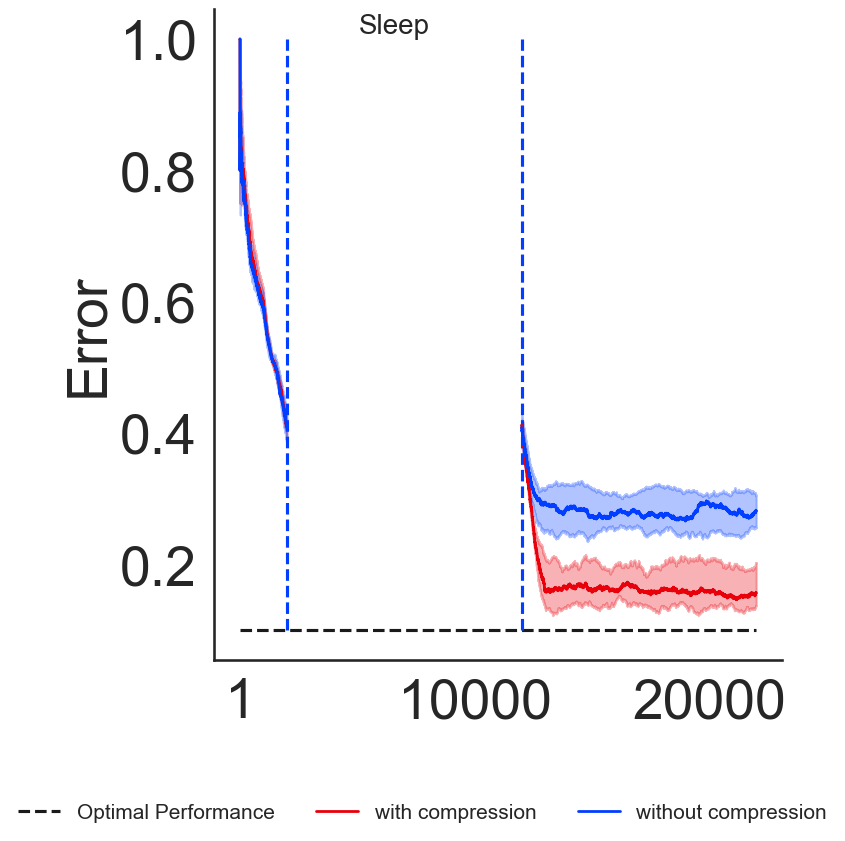

In [1087]:
test_acc = np.array(test_acc)
test_acc_control = np.array(test_acc_control)

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

ax.hlines(0.1, 0, 22000, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.median(1-test_acc[:,:initial_training_sample],axis=0),linewidth=2, color='r', label='with compression')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc[:,:initial_training_sample], 0.75, axis=0), color='r', alpha=.3)

ax.vlines(initial_training_sample, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(initial_training_sample+10000, 0.1, 1, linestyles='dashed', color='b')

ax.plot(np.arange(initial_training_sample+10000,initial_training_sample+10000+len(test_acc[0][initial_training_sample:])), np.median(1-test_acc[:,initial_training_sample:],axis=0),linewidth=2, color='r')
ax.fill_between(np.arange(initial_training_sample+10000,initial_training_sample+10000+len(test_acc[0][initial_training_sample:])), np.quantile(1-test_acc[:,initial_training_sample:], 0.25, axis=0), np.quantile(1-test_acc[:,initial_training_sample:], 0.75, axis=0), color='r', alpha=.3)


ax.plot(np.median(1-test_acc_control[:,:initial_training_sample],axis=0),linewidth=2, color='b', label='without compression')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.75, axis=0), color='b', alpha=.3)

ax.plot(np.arange(initial_training_sample+10000,initial_training_sample+10000+len(test_acc_control[0][initial_training_sample:])), np.median(1-test_acc_control[:,initial_training_sample:],axis=0),linewidth=2, color='b')
ax.fill_between(np.arange(initial_training_sample+10000,initial_training_sample+10000+len(test_acc_control[0][initial_training_sample:])), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.25, axis=0), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.75, axis=0), color='b', alpha=.3)


plt.xticks([1, 10000, 20000])
# plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.text(.42, .92, 'Sleep', rotation=0, fontsize=20)
fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=3, loc='upper center', fontsize=15, frameon=False)
plt.tight_layout()


In [1214]:
hidden_size = 20
total_sample = 10000

data = get_sequence(total_sample, 2, 3, random_state=rep)
# data = pd.read_csv("../Seq_500000.txt")['seq'][0]
acc = []  
    
data_set = Dataset_converter(data, working_memory, short_term_memory)

main_model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = main_model(X)
    else:
        predicted_y, hidden = main_model(X, mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {acc[-1]:.4f}')

Iter : 1001, loss: 1.5097, accuracy: 0.4140
Iter : 2001, loss: 1.4712, accuracy: 0.6720
Iter : 3001, loss: 0.6130, accuracy: 0.8050
Iter : 4001, loss: 0.5643, accuracy: 0.7890
Iter : 5001, loss: 1.5207, accuracy: 0.8100
Iter : 6001, loss: 0.6975, accuracy: 0.7950
Iter : 7001, loss: 0.2987, accuracy: 0.7810
Iter : 8001, loss: 0.4569, accuracy: 0.7920
Iter : 9001, loss: 0.8758, accuracy: 0.8030


# RNN gets stuck if I take argmax

In [1188]:
seq = ''
for ii in tqdm(range(1000)):
    if ii == 0:
        idx = X.reshape(1,1,-1).argmax(axis=2)[0][0]
        # seq += tokens[idx]
        
        X_hat, mem = main_model(X.reshape(1,1,-1))
    else:
        X_hat, mem = main_model(X_hat, mem)

    # mem = mem + 1e-1*torch.rand(mem.shape)
    X_hat = ((X_hat == X_hat.max(axis=1)[0])*1.0).reshape(1,1,-1)   
    idx = X_hat.argmax(axis=2)[0][0]

    if ii>5:
        seq += tokens[idx]

print('Generated sequence ', seq)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 9528.18it/s]

Generated sequence  FDGDEFDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDFEDGDFEDGDEFDGDFEDGDF

# Problem solved after probabilistic sampling

In [1215]:
seq = ''
for ii in tqdm(range(1000)):
    if ii == 0:
        idx = X.reshape(1,1,-1).argmax(axis=2)[0][0]
        # seq += tokens[idx]
        
        X_hat, mem = main_model(X.reshape(1,1,-1))
    else:
        X_hat, mem = main_model(X_hat, mem)

    # mem = mem + 1e-1*torch.rand(mem.shape)
    # X_hat = torch.tensor(X_hat, requires_grad=False)
    X_hat = torch.nn.functional.softmax(X_hat, dim=1)
    dist_categ = dist.Categorical(probs=X_hat.reshape(-1))
    idx = dist_categ.sample()

    X_hat = torch.zeros(len(tokens),dtype=torch.float32)
    X_hat[idx] = 1.0
    X_hat = X_hat.reshape(1,1,-1)   

    if ii>10:
        seq += tokens[idx]

print('Generated sequence ', seq)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6248.63it/s]

Generated sequence  GABCAGACBAGDFEDGABCAGDFEDGDFEDGDFEDGDEFAGDFEDGACBAGDFEDGAGBAGDFEDGACBAGACBAGACBAGDEFDGDFEDGDFEDGDEFDGDFEDGABCAGDEFDGDEFDGACBAGDFEDGABCAGACCAGDFEDGDFEDGABCAGDEFDGACBAGDEFDGABCAGDEFDGDFEDGACBAGDFEDGACBAGACBAGDFEDGACBAGDFEDGDFEFCBAGACBAGACBAGABCAGACBAGABCDGACCAGABCAGACBAGDEFDGACBAGDFEDGDFEDGDEFDGDFEDGDFEDGABCAGACBAGACBAGACBAGDEFDGABCAGDFEDGABCAGACBAGAEFABDEFECBCAGABCAGDFEDGDFEDGABCAGACBAGDBEDGABCAGABCAGABCAGABCAGACBAGDFEDGABCAGDFFDGACBAGDEFDGDFEDGDFEDGDBEDGDFEDGABCAGDEFDGACBAGABCAGACBAGDEFDGDEFDGDFEDGDFEDGDFEDGACBAGDFEDGABCAGDFEDGDEFDGDEFDGABCAGABCAGDFEDGACBAGDEFDGDFEDGABCAGACBAGDEFDGDFEDGDFEDGDEFDGACBAGABCAGACBAGACBEDGDFEDGDEFDGDEFDGABCAGABCAGDEFDGACBAGACBAGABAGABDGDEFDGABCAGACBAGDEFDGDFEDGDEFDGABCAGAGDAEDGABCAGDFEDGABCAGDFEDGDFEDGABCAGABCAGABCAGDEFDGDBFAGACBAGDFEDGACBAGACBAGDFEDGABBAGDFEDGACBAGDEFDGACBAGDFEDGDFEDGDFFDGABCAGDEFAGACBAGABCAGDFEDGABCAGACBAGABCAGABCAGDFEDGABCAGDEFDGDFEDGDFEDGDEFDGACBAGABCAGDFEDGACBAGDEFDGABCAGDFEDGDFEDGDFEDGACBAGDFEDGABCAGABCAGDFEDGACBAGD

# Do sleep experiment with RNN as generative model 

In [1264]:
def generate_sleep_samples(main_model, n_samples):
    seq = ''
    idx = torch.randint(0, len(tokens), (1,)) [0]
    X_hat = torch.zeros(len(tokens),dtype=torch.float32)
    X_hat[idx] = 1.0
    
    for ii in range(n_samples+50):
        if ii == 0:
            # seq += tokens[idx]        
            X_hat, mem = main_model(X_hat.reshape(1,1,-1))
        else:
            X_hat, mem = main_model(X_hat, mem)
    
        # mem = mem + 1e-1*torch.rand(mem.shape)
        # X_hat = torch.tensor(X_hat, requires_grad=False)
        X_hat = torch.nn.functional.softmax(X_hat, dim=1)
        dist_categ = dist.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()
    
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)   
    
        if ii>50:
            seq += tokens[idx]

    return seq

In [1356]:
### initial training ###
total_samples = 250000
initial_training_sample = 30000
sleeping_duration = 200000
working_memory = 1
short_term_memory = 1
working_memory_after_sleep = 4
hidden_size = 20
num_layers = 1
lr = 1e-3
lr_sleep = 5e-4
reps = 1
test_acc = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    
    
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for X, y in train_loader:
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            # print(hidden)
            # mem1 = hidden[0].clone()
            # mem2 = hidden[1].clone()
            # mem = (mem1,mem2)
            mem = hidden.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')
    
    
    ## train sleep models ##
    data_sleep = generate_sleep_samples(main_model, sleeping_duration)
    # data[initial_training_sample:initial_training_sample+sleeping_duration]
    sleep_models = []
    for compression in range(2,working_memory_after_sleep+1):
        print('Doing sleep model ',compression-1)

        data_set = Dataset_converter_compressed(data_sleep, compression, compression, 1)
        # print(len(data_set))
        sleep_models.append(
            RNN(len(tokens), hidden_size, num_layers)
        )
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
        
        optimizer = torch.optim.SGD(sleep_models[-1].parameters(), lr=lr_sleep, momentum=.95)
        criterion = torch.nn.CrossEntropyLoss()
    
        correct_ = np.zeros(1000,dtype=float)
        ii = 0
        for X, y in train_loader:
            optimizer.zero_grad()
    
            if ii == 0:
                predicted_y, hidden = sleep_models[-1](X)
            else:
                predicted_y, hidden = sleep_models[-1](X, mem)
                
            loss = criterion(predicted_y, y)
    
            # if ii<20000:
            loss.backward()
            optimizer.step()
    
            ii += 1
            with torch.no_grad():
                # mem1 = hidden[0].clone()
                # mem2 = hidden[1].clone()
                # mem = (mem1,mem2)
                mem = hidden.clone()
    
                true_y = y.argmax(axis=1)
                estimated_y = predicted_y.argmax(axis=1)
    
                if true_y == estimated_y:
                    correct_[ii%1000] = 1
                else:
                    correct_[ii%1000] = 0
    
                if ii%10000 == 0:
                    print(f'Iter : {ii+1}, loss: {loss:.4f}, accuracy: {np.sum(correct_)/ii if ii<1000 else np.sum(correct_)/1000:.4f}')


    ###### after sleep ######
    data_set = Dataset_converter(data[initial_training_sample+sleeping_duration:initial_training_sample+sleeping_duration+10000], working_memory_after_sleep, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

    # correct = np.zeros(1000,dtype=float)
    ii = 0
    hidden_sleep = [mem]*(working_memory_after_sleep-1)
    for X, y in test_loader:
    
        with torch.no_grad():
            if ii == 0:
                predicted_y, hidden = main_model(X[0,0,-len(tokens):].reshape(1,1,len(tokens)))
            else:
                predicted_y, hidden = main_model(X[0,0,-len(tokens):].reshape(1,1,len(tokens)), hidden)
    
            for jj, model in enumerate(sleep_models):
                if ii == 0:
                    predicted_y_, hidden_ = model(X[0,0,-(jj+2)*len(tokens):-(jj+1)*len(tokens)].reshape(1,1,len(tokens)))
                else:
                    predicted_y_, hidden_ = model(X[0,0,-(jj+2)*len(tokens):-(jj+1)*len(tokens)].reshape(1,1,len(tokens)), hidden_sleep[jj])
    
                # print(hidden_sleep)
                hidden_sleep[jj] = hidden_
                
                # if jj == 0:
                #     predicted_y = predicted_y_
                # else:
                predicted_y += predicted_y_
        
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            # break
            ii += 1
            if true_y == estimated_y:
                correct[ii%1000] = 1
            else:
                correct[ii%1000] = 0
        
            test_acc[rep].append(
                np.sum(correct)/1000
            )
    print(test_acc[rep][-10:])

Doing rep  0
Iter : 1001, loss: 1.5247, accuracy: 0.4320
Iter : 2001, loss: 1.4354, accuracy: 0.7170
Iter : 3001, loss: 0.3710, accuracy: 0.7950
Iter : 4001, loss: 0.7933, accuracy: 0.8120
Iter : 5001, loss: 1.2398, accuracy: 0.8140
Iter : 6001, loss: 1.1052, accuracy: 0.8040
Iter : 7001, loss: 0.5036, accuracy: 0.8030
Iter : 8001, loss: 1.3332, accuracy: 0.8180
Iter : 9001, loss: 0.6945, accuracy: 0.8140
Iter : 10001, loss: 0.7854, accuracy: 0.8070
Iter : 11001, loss: 0.6669, accuracy: 0.7870
Iter : 12001, loss: 1.2817, accuracy: 0.8140
Iter : 13001, loss: 0.7234, accuracy: 0.8170
Iter : 14001, loss: 0.6656, accuracy: 0.8010
Iter : 15001, loss: 0.4139, accuracy: 0.7910
Iter : 16001, loss: 0.8657, accuracy: 0.8150
Iter : 17001, loss: 0.5169, accuracy: 0.8090
Iter : 18001, loss: 1.4179, accuracy: 0.8060
Iter : 19001, loss: 0.8311, accuracy: 0.7760
Iter : 20001, loss: 0.6532, accuracy: 0.8190
Iter : 21001, loss: 1.7562, accuracy: 0.8180
Iter : 22001, loss: 0.9035, accuracy: 0.8250
Iter :

# To-dos
- use RNN as generative model
- review wavelet literature
- do experiments with longer sequence

In [1355]:
data_sleep[:2000]

'GABCAGDEFDGDFEDGABCAGDEFDGABCAGABCAGACBAGACBAGABCAGABCAGDFEDGDEFDGDFEDGDFEDGDEFDGDEFDGDEFDGDFEDGDEFDGDEFDGDFEDGACBAGDFEDGDEFDGDEFDGACBAGDEFDGDEFDGACBAGABCAGDEFDGDEFDGDEFDGABCAGDEFDGACBAGDFEDGDEFDGACBAGACBAGDFEDGABCAGDEFDGDEFDGDFEDGABCAGDFEDGDEFDGDEFDGACBAGACBAGABCAGDFEFGDEFDGDEFDGACBAGDEFDGDEEDGABCAGDEFDGDFDDGDFEDGABCAGACCAGDEFDGDEFDGACBAGACBAGABCAGDEFDGDEFDGACBAGACBAGDEFDGACBAGABCAGACBAGABCAGDFEDGACBAGACBAGABCAGABCAGDEFDGDFEDGDFEDGACBAGABCAGDEFDGDEFDGDEFDGABCAGDFEDGACBAGACBAGDEFDGABCAGDEFDGABCAGACBAGDEFDGABCAGABCAGACBAGABCAGDEFDGDFEDGACBAGDEFDGABCAGDFEDGABCAGACBAGABCAGACBAGABCAGDFEDGDEFDGDEFDGDFEDGDFEDGABCAGDFEDGDEFDGACBAGABCAGDEFDGACBAGDEFDGDEFDGABCAGABCAGDEFDGABCAGACBAGABCAGABCAGDEFDGACBAGDEFDGACCAGDFEDGDEFDGDEFDGDFEDGABCAGDEEDGACBAGABCAGDEFDGDEFDGACBAGACBAGABCAGDEFDGDEFDGACBAGDFEDGDEFDGDFEDGACBAGDEFDGDEFDGDEFDGDEEDGABCAGABCAGDFEDGDEFDGDFEDGDFEDGABCAGDEFDGDEFDGABCAGDFEDGABCAGDEFDGDEFDGDFEDGDEFDGACBAGABCAGACBAGACBAGDEFDGDEFDGDEFDGDEFDGDFEDGABCAGABCAGDFEDGACBAGABCAGABCAGACBAGDEFDGDEF

In [1348]:
generate_sleep_samples(main_model, 1000)

'EFDGDFEDGABCAGDEFDGDFEDGACBAGDEFDGDEFDGDEFDGDEFDGDEFDGDEFDGABCAGDEFDGDEFDGABCAGDEFDGABCAGDFEDGDEFDGDEFDGDFEDGABCAGDEFDGACBAGDEFDGABCAGDFEDGDEFDGABCAGDEFDGDEFDGABCAGDFEDGABCAGDEFDGABCAGDEFDGDFEDGDEFDGDEFDGACBAGDEFDGABCAGDFEDGABCAGDEFDGABCAGDEFDGDEFDGABCAGDEFDGABCAGDEFDGDEFDGABCAGACBAGDEFDGDEFDGABCAGABCAGDEFDGABCAGDFEDGACBAGDFEDGABCAGDEFDGDEFDGDEEDGDEFDGABCAGABCAGDEFDGDEFDGDEFDGABCAGDEFDGABCAGDEFDGDEFDGABCAGACBAGDFEDGDFEDGACBAGDEFDGDEFDGABCAGDEFDGDEFDGBAGDFEDGDEFDGDEFDGACBAGDEFDGDEFDGABCAGDFEDGABCAGDEFDGDEFDGDEFDGDFEDGDEFDGABCAGDFEDGDFEDGACBAGDFEDGDFEDGDEFDGDEFDGABCAGABCAGABCAGDFEDGABCAGDEFDGDEFDGDFEDGDEFDGABCAGDFEDGDEFDGDFEDGABCAGDEFDGABCAGDEFDGACBAGDEFDGDEFDGACBAGDEFDGDEFDGDEFDGDFEDGDFEDGABCAGDEFDGDEFDGABCAGDEFDGDFEDGDEFDGDEFDGABCAGDFEDGDEFDGABCAGABCAGDEFDGABCAGDFEDGABCAGDFEDGABCAGDEFDGDFEDGABCAGABCAGDFEDGDFEDGDFEDGDEFDGDFEDGABCAGDFEDGDFEDGDEFDGABCAGDEFDGABCAGABCAGDEFDGABCAGABFAGDEFDGDFEDGDEFDGABCAGDEFDGABCAGDEFDGACBAGABCAGDEFDGDFEDGDEFDGABCAGDEFDGABCAGDEFDGDEFDGDEFDGABCAGDEFDGABCAGDF